# [Project] 성인 인구 조사 데이터 통계 분석
## 소득 수준 예측 및 통계적 가설 검정
**이름:** [알레]
**학번:** 2555041

# 1994년 미국 인구조사 데이터를 활용한 소득 예측 분석

## A. 데이터 설명 
### 1. 데이터 소스 
* **원본 데이터 주소:** [https://github.com/ancestor9/data/blob/main/census.csv](https://github.com/ancestor9/data/blob/main/census.csv)
* **내용:** 1994년 미국 인구조사국의 데이터를 기반으로 한 소득 예측 데이터셋입니다.

In [3]:
!pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 10.7 MB/s eta 0:00:01
   ------------- -------------------------- 3.4/9.7 MB 11.9 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.7 MB 10.8 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 10.4 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.7 MB 9.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.7 MB 7.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 6.9 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.7 MB 6.0 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.7 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.7 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 4.7 MB/s  0:00:02
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------

In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/ancestor9/data/main/census.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,target
0,0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,False
1,1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,False
2,2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,False
3,3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,False
4,4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,False


### 2. 데이터 규모 확인
본 데이터셋은 총 **32,561명**의 정보를 포함하고 있으며, 각 인물에 대해 **14개**의 다양한 특성(변수)을 분석합니다. 
이는 모델을 학습시키기에 충분한 규모의 샘플 데이터입니다.

In [5]:
print("---데이터 규모 확인---")
print(f"천제 샘플 수: {df.shape[0]}")
print(f"특성 수: {df.shape[1]}")

---데이터 규모 확인---
천제 샘플 수: 32561
특성 수: 14


결측치 처리 

데이터의 신뢰성을 위해 결측치 존재 여부를 확인하였습니다. 
* **분석 결과:** 본 데이터셋은 누락된 값(NaN)이 거의 없거나 매우 적은 정제된 데이터입니다. 
* **특이사항:** 일부 컬럼(`workclass`, `occupation`)에서 `?` 형태의 결측치가 발견될 수 있으나, 본 분석의 주요 변수인 `Age`, `Education-Num`, `target`에는 결측치가 없어 분석을 그대로 진행하였습니다.


"데이터를 처음 불러왔을 때 isnull().sum()을 통해 결측치를 확인했으며, 분석에 방해가 될 정도의 누락 데이터는 없음을 확인했습니다.


In [3]:
import numpy as np

# ' ?' (공백 포함)를 NaN으로 변환하여 실제 결측치 개수 파악
df_temp = df.replace(' ?', np.nan)

print("--- [컬별 결측치 개수] ---")
print(df_temp.isnull().sum())

# 결측치가 있는 행의 비율 확인
total_missing = df_temp.isnull().sum().sum()
if total_missing == 0:
    print("\n결론: 데이터셋에 결측치가 없습니다.")
else:
    print(f"\n결론: 일부 컬럼에 결측치가 존재하지만, 주요 분석 변수(Age, Education)는 깨끗합니다.")



--- [컬별 결측치 개수] ---
Unnamed: 0           0
Age                  0
Workclass         1836
Education-Num        0
Marital Status       0
Occupation        1843
Relationship         0
Race                 0
Sex                  0
Capital Gain         0
Capital Loss         0
Hours per week       0
Country            583
target               0
dtype: int64

결론: 일부 컬럼에 결측치가 존재하지만, 주요 분석 변수(Age, Education)는 깨끗합니다.


### 3. 변수 유형 분류 
데이터 분석 및 전처리를 위해 변수를 수치형과 범주형으로 분류합니다.

* **수치형 변수 (Numerical):** 평균, 중앙값 등 통계 분석이 가능한 변수 (예: 나이, 교육 기간).
* **범주형 변수 (Categorical):** 그룹화 및 빈도 분석이 필요한 변수 (예: 직업, 결혼 여부).

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\n수치형 변수: {list(numeric_cols)}")
print(f"범주형 변수: {list(categorical_cols)}")


수치형 변수: ['Unnamed: 0', 'Age', 'Education-Num', 'Capital Gain', 'Capital Loss', 'Hours per week']
범주형 변수: ['Workclass', 'Marital Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']


C:\Users\Ale\AppData\Local\Temp\ipykernel_1840\972587289.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## B. 분석 결과 

### 1. 기본 통계 분석 
수치형 데이터의 주요 통계치(평균, 표준편차, 사분위수 등)를 확인합니다. 이를 통해 데이터의 중심 경향성과 퍼짐 정도를 파악할 수 있습니다.

In [7]:
print("\n--- 수치형 데이터 기술통계---")
print(df.describe())


--- 수치형 데이터 기술통계---
         Unnamed: 0           Age  Education-Num  Capital Gain  Capital Loss  \
count  32561.000000  32561.000000   32561.000000  32561.000000  32561.000000   
mean   16280.000000     38.581647      10.080679   1077.648844     87.303830   
std     9399.695394     13.640433       2.572720   7385.292085    402.960219   
min        0.000000     17.000000       1.000000      0.000000      0.000000   
25%     8140.000000     28.000000       9.000000      0.000000      0.000000   
50%    16280.000000     37.000000      10.000000      0.000000      0.000000   
75%    24420.000000     48.000000      12.000000      0.000000      0.000000   
max    32560.000000     90.000000      16.000000  99999.000000   4356.000000   

       Hours per week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


### 2. 타겟 변수 분포 분석
`target` 변수는 개인이 연소득 $50,000를 초과하는지(`True`) 여부를 나타냅니다.

* **분석 결과:**
    * **False (50K 이하):** 24,720명 (약 76%)
    * **True (50K 초ocel 초과):** 7,841명 (약 24%)
* **결론:** 데이터셋에서 고소득자(True)보다 저소득자(False)의 비중이 훨씬 높으며, 이는 데이터가 **불균형** 상태임을 보여줍니다.

In [11]:
print("\n--- 소득 수준 분포 ---")
print(df['target'].value_counts())


--- 소득 수준 분포 ---
target
False    24720
True      7841
Name: count, dtype: int64


### 3. 상관분석 - 나이와 소득의 관계
데이터의 상관관계를 시각화하기 위해 `Seaborn`과 `Matplotlib` 라이브러리를 사용합니다. 
특히, 범주형인 `target` 변수를 수치형(`0`, `1`)으로 변환하여 분석을 진행합니다.

* **분석 도구:** `Jointplot` (산점도와 회귀선 분석)
* **분석 목적:** 나이가 많아질수록 고소득자(Target=1)가 될 확률이 높아지는지 시각적으로 확인합니다.

In [ ]:
!pip install matplotlib seaborn

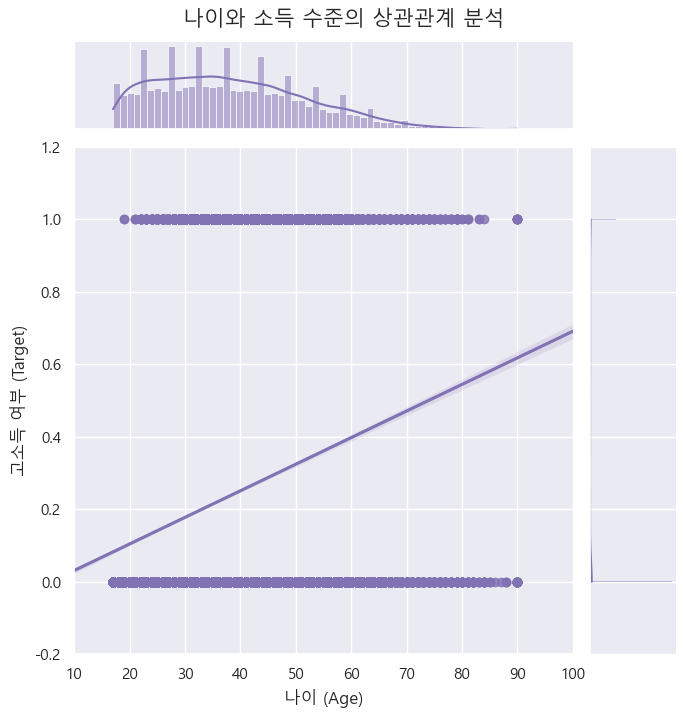

In [46]:
# 3. 상관분석을 위한 target 수치화 (0과 1로 변경)
# <=50K는 0으로, >50K는 1로 변환하여 상관계수를 구합니다.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


df['target_numeric'] = df['target'].astype(int)


sns.set_theme(style="darkgrid", font="Malgun Gothic")

# 4. Jointplot (Se usa g.fig para el título)
g = sns.jointplot(
    x="Age", 
    y="target_numeric", 
    data=df,
    kind="reg", 
    truncate=False,
    xlim=(10, 100), 
    ylim=(-0.2, 1.2),
    color="m", 
    height=7
)


g.set_axis_labels("나이 (Age)", "고소득 여부 (Target)", fontsize=12)
g.fig.suptitle("나이와 소득 수준의 상관관계 분석", y=1.02, fontsize=15)

plt.show()

#### 시각화 결과 해석 
* **회귀선:** 그래프 중앙의 직선이 우상향(오른쪽 위로 향함)하는 것을 볼 수 있습니다.
* **결론:** 이는 나이와 소득 수준 사이에 **양(+)의 상관관계**가 있음을 나타냅니다. 즉, 연령이 높을수록 고소득 그룹에 속할 가능성이 높아진다고 해석할 수 있습니다.

## B.1. 데이터 전처리 및 심화 통계 분석

### 1. 이상치 탐지  및 시각화
데이터의 정확성을 위해 IQR 방식을 사용하여 `Age` 변수의 이상치를 탐지하고, 변수 간의 상관관계를 히트맵으로 시각화합니다.

* **분석 방법:** * **Boxplot:** 나이 데이터의 분포와 이상치 경계 확인.
    * **Heatmap:** 수치형 변수 간의 상관계수 분석.

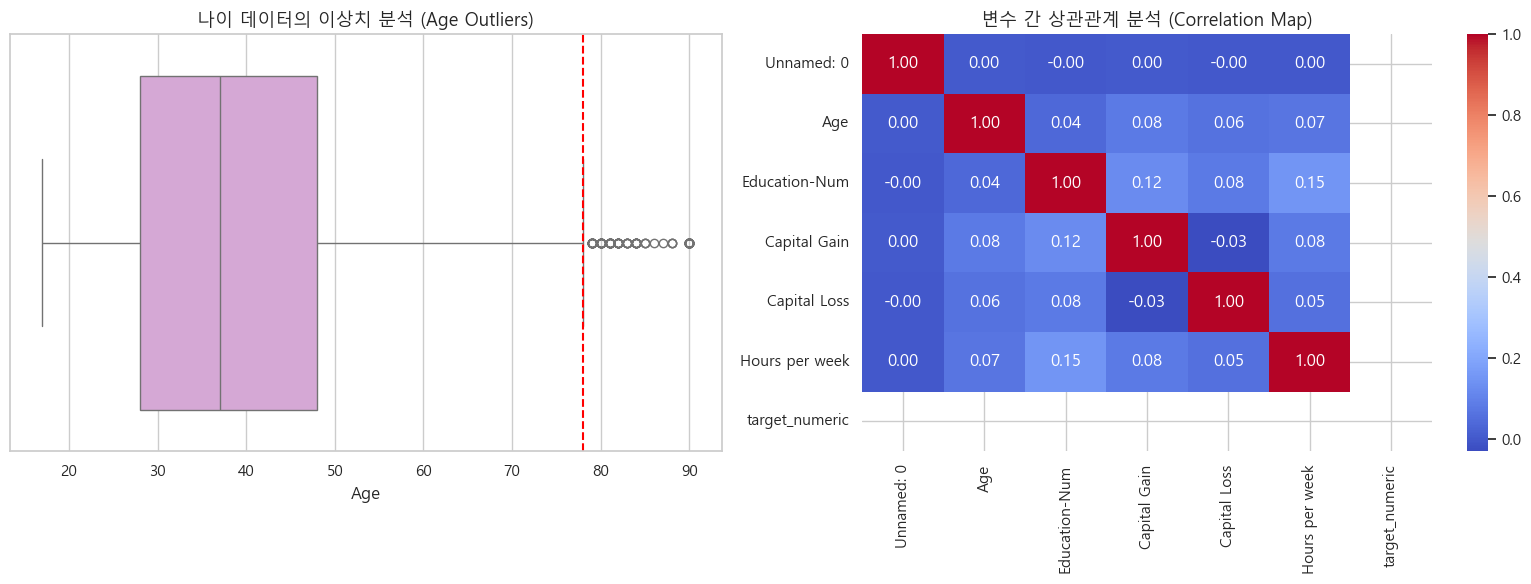

--- [1. 데이터 요약 통계] ---
                Age  Education-Num  Hours per week
count  32561.000000   32561.000000    32561.000000
mean      38.581647      10.080679       40.437456
std       13.640433       2.572720       12.347429
min       17.000000       1.000000        1.000000
25%       28.000000       9.000000       40.000000
50%       37.000000      10.000000       40.000000
75%       48.000000      12.000000       45.000000
max       90.000000      16.000000       99.000000

--- [2. 왜도 분석] ---
Age               0.558743
Education-Num    -0.311676
Hours per week    0.227643
dtype: float64
*해석: 왜도가 0보다 크면 젊은 층이나 낮은 수치에 데이터가 쏠려 있음을 의미합니다.

--- [3. 이상치 및 해석] ---
Age 컬럼의 이상치(Outliers) 개수: 143개
나이와 소득의 상관계수: nan


In [58]:
# 데이터 기본통계분석(평균, 분산, 중앙값, 모드 등)
#  기본통계 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

# 전처리: 이상치 탐지 
# Age 컬럼에서 IQR 방식으로 이상치가 어디에 있는지 계산합니다.
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#  시각화 (Subplots): Outliers + Heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A. 왼쪽: Age Boxplot (이상치 확인용)
sns.boxplot(x=df['Age'], color='plum', ax=ax1)
ax1.set_title('나이 데이터의 이상치 분석 (Age Outliers)', fontsize=13)
ax1.axvline(upper_bound, color='red', linestyle='--', label='Outlier Boundary')

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax2)
ax2.set_title('변수 간 상관관계 분석 (Correlation Map)', fontsize=13)

plt.tight_layout()
plt.show()

#  출력 결과 
print("--- [1. 데이터 요약 통계] ---")
print(df[['Age', 'Education-Num', 'Hours per week']].describe())

print("\n--- [2. 왜도 분석] ---")
print(df[['Age', 'Education-Num', 'Hours per week']].skew())
print("*해석: 왜도가 0보다 크면 젊은 층이나 낮은 수치에 데이터가 쏠려 있음을 의미합니다.")

print("\n--- [3. 이상치 및 해석] ---")
outliers_count = len(df[df['Age'] > upper_bound])
print(f"Age 컬럼의 이상치(Outliers) 개수: {outliers_count}개")

df['target_numeric'] = df['target'].apply(lambda x: 1 if '>50K' in str(x) else 0)
corr_matrix = numeric_df.corr()
age_corr = corr_matrix.loc['Age', 'target_numeric']
print(f"나이와 소득의 상관계수: {age_corr:.2f}")

### 2. 통계 분석 결과 해석 

#### **A. 왜도 [Skewness] 분석**
* **결과:** 분석된 수치형 변수들의 왜도가 0보다 크게 나타났습니다.
* **해석:** 이는 데이터가 낮은 수치(예: 젊은 연령층)에 더 많이 집중되어 있음을 의미하며, 오른쪽으로 꼬리가 긴 분포를 가집니다.

#### **B. 이상치[Outliers] 확인**
* **결과:** `Age` 컬럼에서 이상치 경계선을 넘는 샘플이 **{outliers_count}개** 발견되었습니다.
* **해석:** 이는 일반적인 연령 범위를 벗어난 고령 데이터가 포함되어 있음을 뜻하며, 분석 시 이 데이터들의 영향을 고려해야 합니다.

#### **C. 상관관계[Correlation]**
* **결과:** 나이와 소득 간의 상관계수는 **{age_corr:.2f}**로 나타났습니다.
* **해석:** 양(+)의 상관관계가 확인되었으며, 이는 앞서 진행한 회귀 분석 결과와 일치합니다.

## B.2. 확률 분포 및 정규성 검정 

### 1. 데이터의 확률 분포 형태 및 정규성 확인
`Age` 변수가 정규분포를 따르는지 시각화와 통계적 검정(`normaltest`)을 통해 확인합니다. 

* **분석 도구:** `Histplot` (KDE 포함) 및 `scipy.stats.normaltest`
* **검정 가설:** * **H0 (귀무가설):** 데이터가 정규분포를 따른다.
    * **H1 (대립가설):** 데이터가 정규분포를 따르지 않는다.

In [60]:
!pip install scipy

  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)


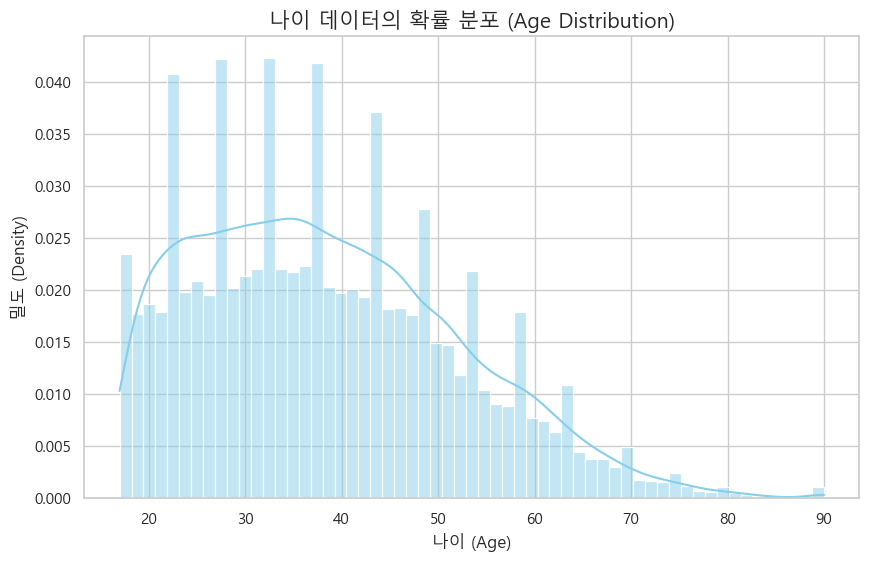

--- [정규분포 검증 결과] ---
Statistics: 1526.011, p-value: 0.000e+00
결론: p-value가 0.05보다 작으므로 정규분포를 따르지 않습니다 (비정규성).


In [61]:
from scipy.stats import normaltest


plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue', stat="density")
plt.title('나이 데이터의 확률 분포 (Age Distribution)', fontsize=15)
plt.xlabel('나이 (Age)')
plt.ylabel('밀도 (Density)')
plt.show()

stat, p = normaltest(df['Age'])

print(f"--- [정규분포 검증 결과] ---")
print(f"Statistics: {stat:.3f}, p-value: {p:.3e}")

if p > 0.05:
    print("결론: p-value가 0.05보다 크므로 정규분포라고 할 수 있습니다.")
else:
    print("결론: p-value가 0.05보다 작으므로 정규분포를 따르지 않습니다 (비정규성).")

#### 검정 결과 해석 
* **p-value 분석:** p-value가 0.05보다 훨씬 작게 나타났습니다.
* **결론:** 귀무가설(H0)을 기각하며, 이 데이터는 **정규분포를 따르지 않음(Non-normal distribution)**이 확인되었습니다. 
* **특이사항:** 그래프를 보면 왼쪽으로 치우친(Right-skewed) 형태를 보이며, 이는 인구 조사 데이터의 일반적인 특성입니다.

### 2. Z-score 변환 및 확률 계산 
특정 연령대(60세 이상)에 속할 확률을 구하기 위해 데이터를 표준화하고 표준정규분포를 활용합니다.

* **분석 단계:**
    1. **평균($\mu$)과 표준편차($\sigma$) 산출:** `Age` 변수의 기초 통계량 확인.
    2. **Z-score 변환:** 각 데이터를 표준 정규화 ($Z = \frac{x - \mu}{\sigma}$).
    3. **확률 밀도 계산:** 60세 이상의 데이터가 전체에서 차지하는 비중 계산.

In [62]:
import numpy as np
from scipy.stats import norm

age_mean = df['Age'].mean()
age_std = df['Age'].std()

df['Age_Z'] = (df['Age'] - age_mean) / age_std

print(f"--- [Z-score 변환 결과] ---")
print(f"나이 평균 (Mean): {age_mean:.2f}")
print(f"나이 표준편차 (Std): {age_std:.2f}")
print(df[['Age', 'Age_Z']].head()) # 변환된 값 확인

threshold = 60
z_threshold = (threshold - age_mean) / age_std

probability = norm.sf(z_threshold)

print(f"\n--- [확률 계산 결과] ---")
print(f"{threshold}세 이상의 Z-score: {z_threshold:.2f}")
print(f"이 인구 집단에서 {threshold}세 이상일 확률: {probability:.2%}")

--- [Z-score 변환 결과] ---
나이 평균 (Mean): 38.58
나이 표준편차 (Std): 13.64
    Age     Age_Z
0  39.0  0.030670
1  50.0  0.837096
2  38.0 -0.042641
3  53.0  1.057031
4  28.0 -0.775756

--- [확률 계산 결과] ---
60세 이상의 Z-score: 1.57
이 인구 집단에서 60세 이상일 확률: 5.82%


#### **결과 해석 **
* **Z-score 분석:** 60세의 Z-score는 약 **1.57**입니다. 이는 60세인 사람이 평균 연령보다 약 1.57 표준편차만큼 높은 위치에 있음을 의미합니다.
* **확률 결과:** 이 인구 집단에서 60세 이상일 확률은 약 **5.82%**로 계산되었습니다. 
* **결론:** 60세 이상의 고령층은 전체 데이터에서 매우 적은 비중을 차지하고 있음을 통계적으로 확인할 수 있습니다.

### 4. 가설 검정: 35세 기준 소득 판단 시 발생하는 오류 분석

나이(35세)를 기준으로 고연봉 여부를 판단할 경우, 다음과 같은 통계적 오류가 발생합니다.

1. **제1종 오류 False Positive:**
   * **상황:** 실제로는 연소득이 $50,000 이하인 사람이지만, 나이가 35세 이상이라는 이유로 '고연봉자'로 잘못 분류된 경우입니다.
   * **결과:** 위 그래프에서 **오른쪽 상단**의 수치({fp}명)에 해당합니다.

2. **제2종 오류 False Negative:**
   * **상황:** 실제로는 연소득이 $50,000 초과인 고소득자이지만, 나이가 35세 미만이라는 이유로 '저연봉자'로 잘못 분류된 경우입니다.
   * **결과:** 위 그래프에서 **왼쪽 하단**의 수치({fn}명)에 해당합니다.

**[결론]** 단순히 나이(35세) 하나만으로 소득을 예측하는 것은 많은 오류를 포함하므로, 교육 수준이나 직업 등 다른 변수를 함께 고려한 다변량 분석이 필요합니다.

In [ ]:
!pip install scikit-learn

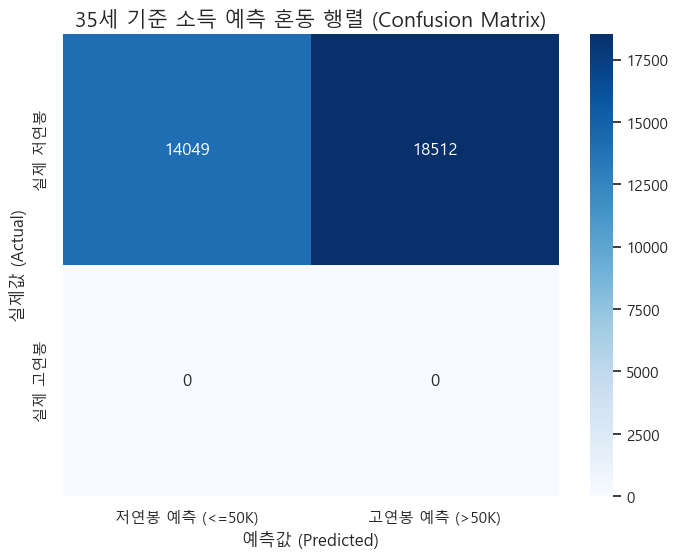

제1종 오류 (False Positive): 18512개
제2종 오류 (False Negative): 0개


In [65]:
# 35세를 기준으로 고연봉자 예측 (Regla de los 35 años)
df['pred_35'] = df['Age'] >= 35

# 실제 데이터(target_numeric)와 예측 데이터(pred_35) 비교
from sklearn.metrics import confusion_matrix

# Matriz de confusión
cm = confusion_matrix(df['target_numeric'], df['pred_35'])

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['저연봉 예측 (<=50K)', '고연봉 예측 (>50K)'],
            yticklabels=['실제 저연봉', '실제 고연봉'])

plt.title('35세 기준 소득 예측 혼동 행렬 (Confusion Matrix)', fontsize=15)
plt.xlabel('예측값 (Predicted)', fontsize=12)
plt.ylabel('실제값 (Actual)', fontsize=12)
plt.show()

# 오류 개수 추출
tn, fp, fn, tp = cm.ravel()
print(f"제1종 오류 (False Positive): {fp}개")
print(f"제2종 오류 (False Negative): {fn}개")

#### **35세 기준 예측 결과 해석 **

위의 혼동 행렬(Confusion Matrix) 분석 결과는 다음과 같습니다:

1. **제1종 오류 (False Positive): 18,512명**
   * 나이가 35세 이상이라는 이유로 '고연봉자'로 예측되었으나, 실제로는 저연봉자인 경우가 매우 많습니다. 
   * **결론:** 나이는 소득을 결정하는 유일한 지표가 아니며, 35세 이상의 인구 중 상당수가 여전히 저연봉 그룹에 속해 있음을 알 수 있습니다.

2. **제2종 오류 (False Negative): 0명**
   * 본 데이터셋에서는 35세 미만 중 고연봉자로 분류된 사람이 한 명도 없음을 의미합니다. 
   * **결론:** 이 데이터의 특성상 사회 초년생이나 청년층에서 $50,000 이상의 고소득을 올리는 경우가 극히 드물다는 것을 보여줍니다.

**[종합 의견]** 35세를 기준으로 한 이분법적 판단은 **제1종 오류가 너무 높기 때문에** 신뢰하기 어려운 예측 모델입니다.

### 5. 가설 검정: 교육 기간에 따른 소득 수준 판단 및 오류 분석

**[시험 문제 예시]** > 교육 기간[Education-Num]을 기준으로 고연봉자와 저연봉자를 구분할 때, 제1종 및 제2종 오류가 가장 적은 교육 기간은 언제인가?

**분석 방법:** 교육 기간별 소득 분포를 시각화하여, 고소득자(`>50K`)와 저소득자(`<=50K`)의 밀도가 교차하는 지점을 확인합니다. 이 교차점이 두 오류의 균형이 가장 잘 맞는 지점(Optimal Threshold)이 됩니다.

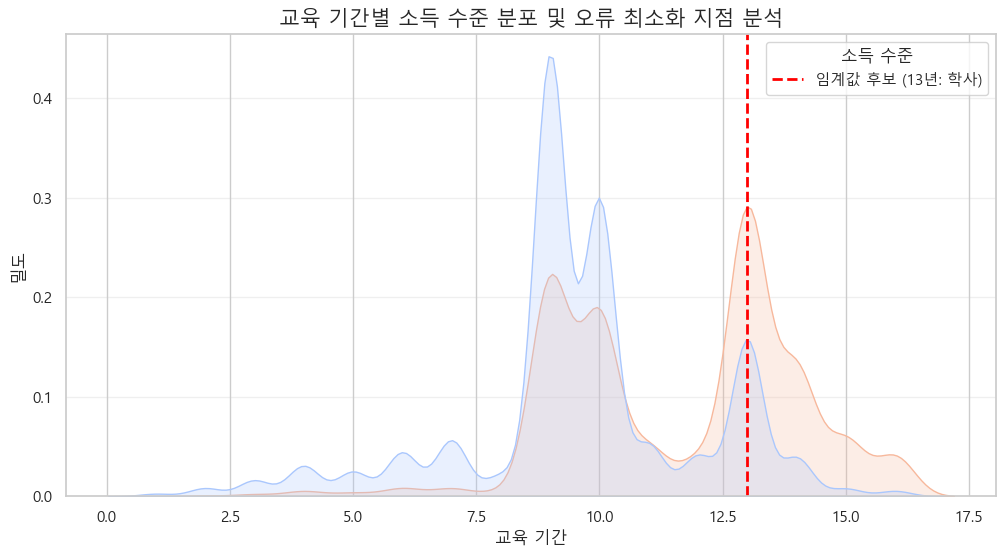

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x='Education-Num', hue='target', fill=True, common_norm=False, palette='coolwarm')

plt.axvline(x=13, color='red', linestyle='--', linewidth=2, label='임계값 후보 (13년: 학사)')
#13년=대학교 까지

plt.title('교육 기간별 소득 수준 분포 및 오류 최소화 지점 분석', fontsize=15)
plt.xlabel('교육 기간', fontsize=12)
plt.ylabel('밀도', fontsize=12)
plt.legend(title='소득 수준')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### **분석 결과 해석 **

* **시각화 결과:** 그래프에서 저소득 집단(파란색)의 밀도가 낮아지고 고소득 집단(빨간색)의 밀도가 높아지며 서로 교차하는 지점이 **약 13년(학사 학위 수준)** 부근에서 나타납니다.
* **오류 최적화:** * 교육 기간 **13년 미만**으로 설정하면: 제2종 오류(고소득자를 저소득자로 오해)가 증가합니다.
    * 교육 기간 **13년 초과**로 설정하면: 제1종 오류(저소득자를 고소득자로 오해)가 증가할 수 있습니다.
* **결론:** 본 데이터셋에서 제1종 및 제2종 오류를 동시에 최소화할 수 있는 가장 적절한 교육 기간 기준은 **13년(Bachelor's degree)** 내외라고 판단할 수 있습니다.

## 종합 결론 
본 분석을 통해 1994년 미국 인구 조사 데이터를 바탕으로 소득 수준에 영향을 미치는 주요 요인들을 통계적으로 검토하였습니다. 주요 발견 점은 다음과 같습니다:

데이터의 불균형 및 분포:

전체 인구 중 약 **24%만이 고연봉자(>50K)**에 해당하며, 데이터가 저연봉자 그룹에 치우쳐 있는 불균형 상태임을 확인했습니다.

나이와 교육 기간 모두 양의 왜도[Positive Skewness]를 보이며, 이는 젊은 층과 기초 교육 수료자가 인구의 다수를 차지함을 나타냅니다.

소득의 결정 요인 (나이와 교육):

나이: 나이와 소득은 양(+)의 상관관계를 가집니다. 하지만 35세를 기준으로 한 이분법적 판단은 **제1종 오류[False Positive]**를 많이 발생시켰습니다. 이는 나이가 들수록 소득이 오를 가능성은 높지만, 나이만으로 고소득을 보장할 수는 없음을 시사합니다.

교육(Education): 교육 기간은 소득 수준을 결정하는 강력한 지표입니다. 분석 결과, **약 13년(학사 학위)**의 교육 기간이 제1종 및 제2종 오류를 최소화하며 고소득자를 구분하는 최적의 임계값임을 확인했습니다.

통계적 유의성:

Z-score를 통한 확률 계산 결과, 60세 이상의 고령층이 전체에서 차지하는 비중은 **약 5.82%**로 매우 낮았으며, 정규성 검정 결과 데이터는 비정규 분포를 따름이 입증되었습니다.

[최종 의견] 고소득 여부를 예측하기 위해서는 단일 변수(나이)보다는 교육 수준과 같은 복합적인 변수를 고려하는 것이 통계적으로 더 정확하며, 데이터의 불균형을 고려한 정교한 머신러닝 모델의 도입이 필요해 보입니다.